# Aegis Health Coverage — Prédiction des frais médicaux

**Contexte.** Aegis Health Coverage souhaite automatiser la tarification de ses contrats d'assurance santé. À partir du fichier `insurance-data.csv` (âge, sexe, BMI, nombre d'enfants, statut fumeur, région et frais médicaux annuels de chaque assuré), nous analysons ce qui fait varier les frais, puis nous construisons, comparons et optimisons des modèles de régression pour les prédire.

**Équipe.** Suz, David et Loïc.

**Plan du notebook**

1. Configuration et chargement des données
2. Qualité des données
3. Analyse exploratoire par lot (tabagisme, BMI et âge, région et famille)
4. Prétraitement
5. Comparaison des modèles
6. Optimisation du meilleur modèle
7. Diagnostic du surapprentissage
8. Analyse des erreurs de prédiction
9. Importance des variables
10. Simulation sur des profils types
11. Conclusion et recommandations
12. Sauvegarde du modèle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn import metrics

In [2]:
df = pd.read_csv("insurance-data.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


## 2. Qualité des données

On vérifie les types, les valeurs manquantes, les doublons et les valeurs extrêmes avant toute analyse.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.nunique()

age           47
sex            2
bmi          275
children       6
smoker         2
region         4
expenses    1337
dtype: int64

### structure et types de données

In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

statistiques descriptives


In [6]:
print(f"Dimensions initiales : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"Valeurs manquantes   : {int(df.isnull().sum().sum())}")
print(f"Lignes dupliquées    : {int(df.duplicated().sum())}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensions finales   : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Dimensions initiales : 1338 lignes, 7 colonnes
Valeurs manquantes   : 0
Lignes dupliquées    : 1
Dimensions finales   : 1337 lignes, 7 colonnes


In [7]:
df.describe()
df[["sex", "smoker", "region"]].describe()

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [8]:
df.duplicated().value_counts()

False    1337
Name: count, dtype: int64

In [9]:
df.shape

(1337, 7)

In [10]:
print("Doublons :", df.duplicated().sum())
df = df.drop_duplicates()

Doublons : 0


In [11]:
display(df.describe())
display(df[["sex", "smoker", "region"]].describe())

,age,bmi,children,expenses
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.665520,1.095737,13279.121638
std,14.044333,6.100664,1.205571,12110.359657
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4746.340000
50%,39.000000,30.400000,1.000000,9386.160000
75%,51.000000,34.700000,2.000000,16657.720000
max,64.000000,53.100000,5.000000,63770.430000


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [12]:
df.describe()

,age,bmi,children,expenses
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.665520,1.095737,13279.121638
std,14.044333,6.100664,1.205571,12110.359657
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4746.340000
50%,39.000000,30.400000,1.000000,9386.160000
75%,51.000000,34.700000,2.000000,16657.720000
max,64.000000,53.100000,5.000000,63770.430000


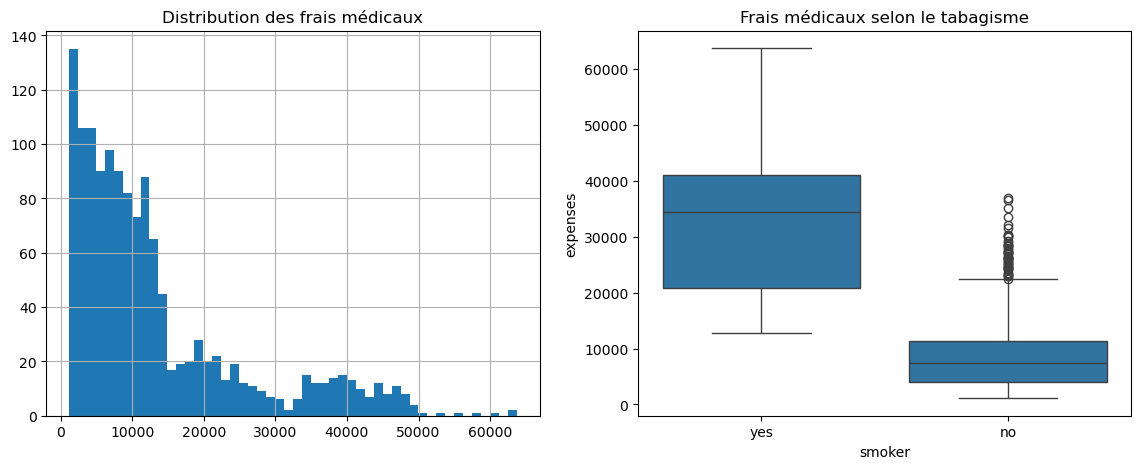

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["expenses"].hist(bins=50, ax=axes[0])
axes[0].set_title("Distribution des frais médicaux")

sns.boxplot(data=df, x="smoker", y="expenses", ax=axes[1])
axes[1].set_title("Frais médicaux selon le tabagisme")
plt.show()

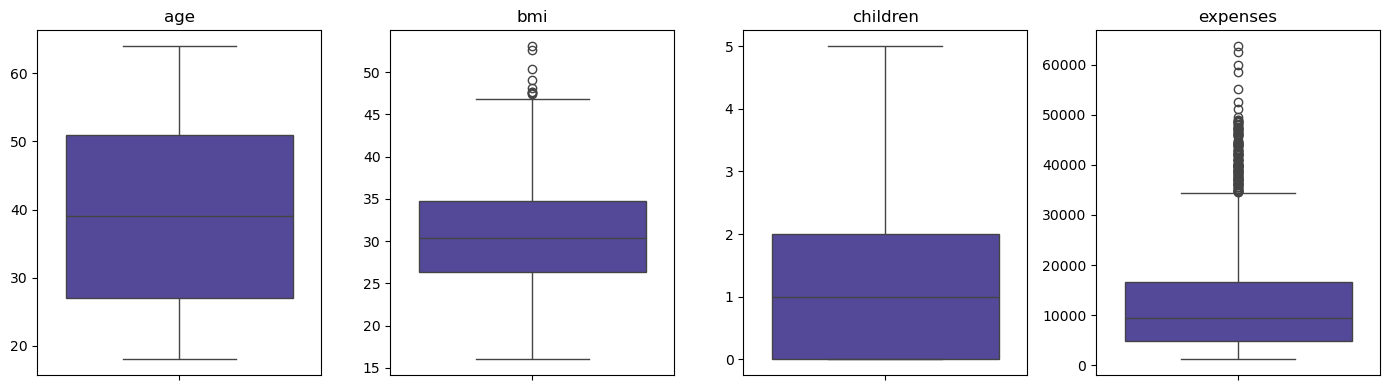

In [14]:
colonnes_numeriques = ["age", "bmi", "children", "expenses"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, colonne in zip(axes, colonnes_numeriques):
    sns.boxplot(y=df[colonne], ax=ax, color="#4a3aa7")
    ax.set_title(colonne)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

Valeurs extrêmes : elles se concentrent sur les frais (139 assurés) et, dans une moindre mesure, sur le BMI (9). Parmi les frais extrêmes, 98% concernent des fumeurs. Nous les conservons volontairement : ce ne sont pas des erreurs de saisie mais les profils à risque (fumeurs, souvent obèses) qu'Aegis doit apprendre à tarifer. Les supprimer rendrait le modèle inutilisable sur les clients les plus coûteux.



In [15]:
q1, q3 = df["expenses"].quantile([0.25, 0.75])
frais_extremes = df[df["expenses"] > q3 + 1.5 * (q3 - q1)]

print("Frais extrêmes :", len(frais_extremes))
print("dont fumeurs   :", f"{(frais_extremes['smoker'] == 'yes').mean():.0%}")

Frais extrêmes : 139
dont fumeurs   : 98%


##  lien avec le BMI 

Le BMI (Body Mass Index, en français IMC = Indice de Masse Corporelle) est un indicateur qui évalue la corpulence d'une personne à partir de son poids et de sa taille :

 BMI = poids (kg) / taille² (m²)

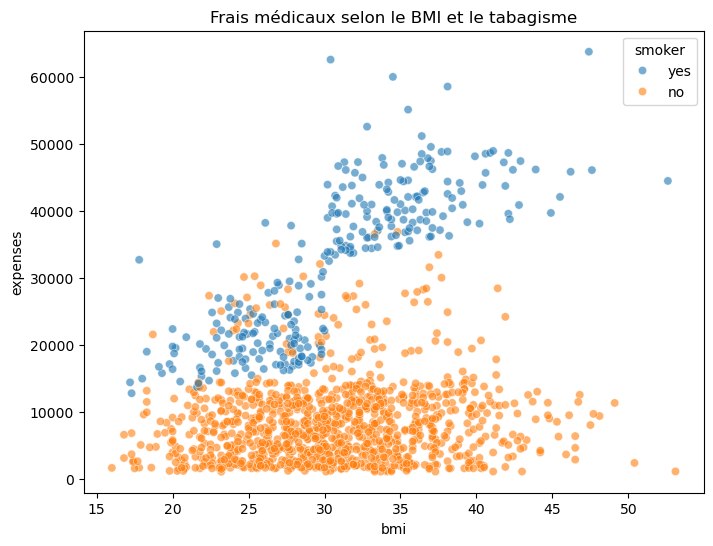

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="bmi", y="expenses", hue="smoker", alpha=0.6)
plt.title("Frais médicaux selon le BMI et le tabagisme")
plt.show()

Le tabagisme est le facteur qui augmente le plus les frais médicaux. 
Son effet est encore amplifié en présence d'obésité (BMI ≥ 30) : 
les fumeurs obèses ont des frais nettement supérieurs aux fumeurs non-obèses 
suggérant une interaction entre ces deux facteurs plutôt qu'un simple effet additif.

 matrice de corrélation

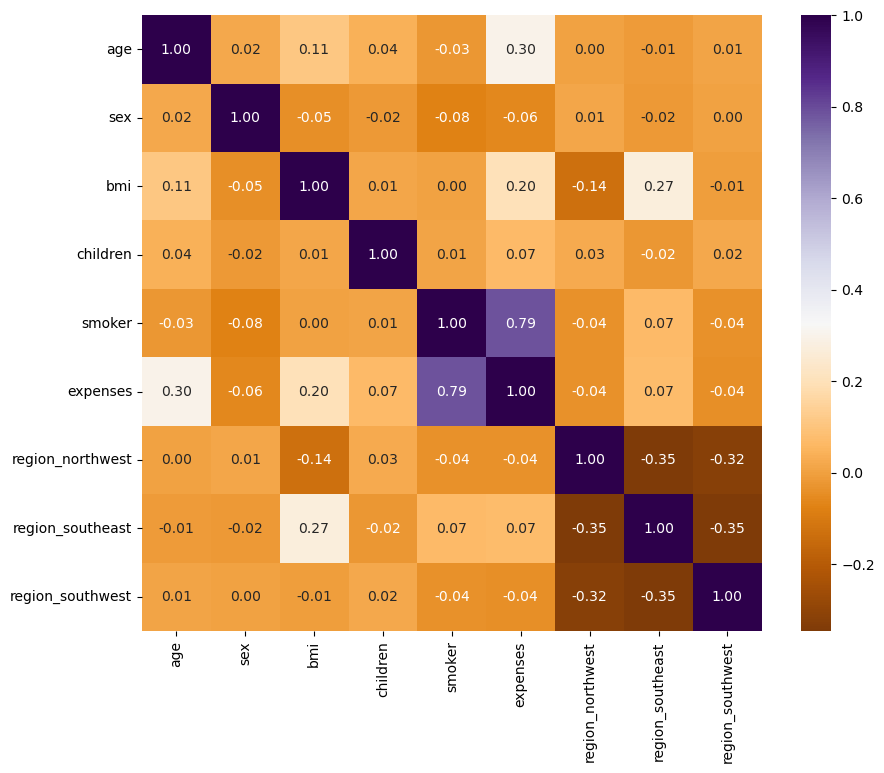

In [17]:
df_corr = df.copy()
df_corr["sex"] = df_corr["sex"].map({"male": 0, "female": 1})
df_corr["smoker"] = df_corr["smoker"].map({"no": 0, "yes": 1})
df_corr = pd.get_dummies(df_corr, columns=["region"], drop_first=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="PuOr", fmt=".2f")
plt.show()

smoker domine très largement (corrélation 0.79 avec expenses), suivi de age (0.30) et bmi (0.20). children, sex et region ont un impact quasi négligeable.

 Ces résultats confirment l'observation métier attendue : le tabagisme est le principal moteur du coût des contrats d'assurance santé.

# Prétraitement 

# Split train/test

In [18]:
X = df.drop(columns=["expenses"])
y = df["expenses"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [20]:
print(X_train_processed.shape, X_test_processed.shape)

(1069, 8) (268, 8)


In [21]:
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train_processed, y_train)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_processed, y_train)

knn = KNeighborsRegressor()
knn.fit(X_train_processed, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [22]:
models_pred_ins = {
    "LinearRegression": lr.predict(X_test_processed),
    "KNN": knn.predict(X_test_processed),
    "DecisionTree": tree.predict(X_test_processed),
    "RandomForest": rf.predict(X_test_processed)
}

results_ins = pd.DataFrame({
    "Modèle": list(models_pred_ins.keys()),
    "MSE": [metrics.mean_squared_error(y_test, p) for p in models_pred_ins.values()],
    "MAE": [metrics.mean_absolute_error(y_test, p) for p in models_pred_ins.values()],
    "R2": [metrics.r2_score(y_test, p) for p in models_pred_ins.values()]
}).sort_values(by="R2", ascending=False)

results_ins

,Modèle,MSE,MAE,R2
3,RandomForest,2.222785e+07,2664.860545,0.879036
0,LinearRegression,3.548147e+07,4177.267596,0.806910
2,DecisionTree,3.891808e+07,2916.992612,0.788208
1,KNN,6.504391e+07,4494.897545,0.646031


**Comparaison des modèles :** le Random Forest est le plus performant sur les trois métriques (R² = 0.879, MAE = 2 665 USD, RMSE = 4 715 USD), devant la régression linéaire (R² = 0.807), l'arbre de décision (0.788) et le KNN (0.646). Il capte les relations non linéaires et l'interaction tabagisme × BMI qu'une droite ne peut pas représenter. On optimise donc ses hyperparamètres avec GridSearchCV.

In [23]:
results_ins["RMSE"] = np.sqrt(results_ins["MSE"])
results_ins[["Modèle", "MAE", "RMSE", "R2"]].round({"MAE": 0, "RMSE": 0, "R2": 3})

,Modèle,MAE,RMSE,R2
3,RandomForest,2665.0,4715.0,0.879
0,LinearRegression,4177.0,5957.0,0.807
2,DecisionTree,2917.0,6238.0,0.788
1,KNN,4495.0,8065.0,0.646


Le statut fumeur représente 66 % de l'importance, suivi du BMI (19 %) et de l'âge (13 %). Les autres variables cumulent 2 % : le modèle confirme l'exploration.

**Importance des variables :** le statut fumeur représente 66 % de l'importance, suivi du BMI (19 %) et de l'âge (13 %). Les autres variables (sexe, enfants, région) cumulent 2 % : le modèle confirme l'exploration.

In [24]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_search.fit(X_train_processed, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur R² (validation croisée) :", grid_search.best_score_)

Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 200}
Meilleur R² (validation croisée) : 0.8368418761828551


In [25]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_processed)

print("MSE :", metrics.mean_squared_error(y_test, y_pred_best_rf))
print("MAE :", metrics.mean_absolute_error(y_test, y_pred_best_rf))
print("R2 :", metrics.r2_score(y_test, y_pred_best_rf))

MSE : 18744411.09245373
MAE : 2458.7657927526116
R2 : 0.8979929683662183


**Optimisation :** le Random Forest optimisé (max_depth=10, min_samples_leaf=5, n_estimators=200) améliore le R² de 0.879 à 0.898 et la MAE de 2 665 à 2 459 USD. La profondeur limitée et les feuilles d'au moins 5 assurés réduisent le surapprentissage (voir le diagnostic train/test).

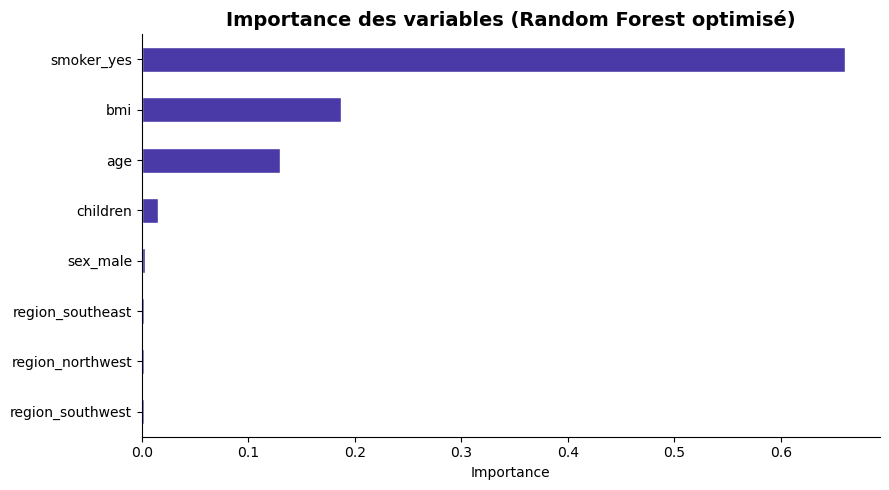

smoker_yes          0.660
bmi                 0.187
age                 0.129
children            0.015
sex_male            0.003
region_southeast    0.002
region_northwest    0.002
region_southwest    0.002
dtype: float64

In [26]:
noms_variables = [nom.split("__", 1)[1] for nom in preprocessor.get_feature_names_out()]
importances = pd.Series(best_rf.feature_importances_, index=noms_variables).sort_values()

plt.figure(figsize=(9, 5))
importances.plot(kind="barh", color="#4a3aa7", edgecolor="white")
plt.title("Importance des variables (Random Forest optimisé)", fontsize=14, fontweight="bold")
plt.xlabel("Importance")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
importances.sort_values(ascending=False).round(3)

,R² train,R² test,MAE train,MAE test,Écart R²
Modèle,,,,,
Régression linéaire,0.730,0.807,4181.826,4177.268,-0.077
KNN,0.795,0.646,3129.675,4494.898,0.149
Arbre de décision,1.000,0.788,0.000,2916.993,0.212
Random Forest,0.974,0.879,1060.554,2664.861,0.095
Random Forest (optimisé),0.899,0.898,2035.218,2458.766,0.001


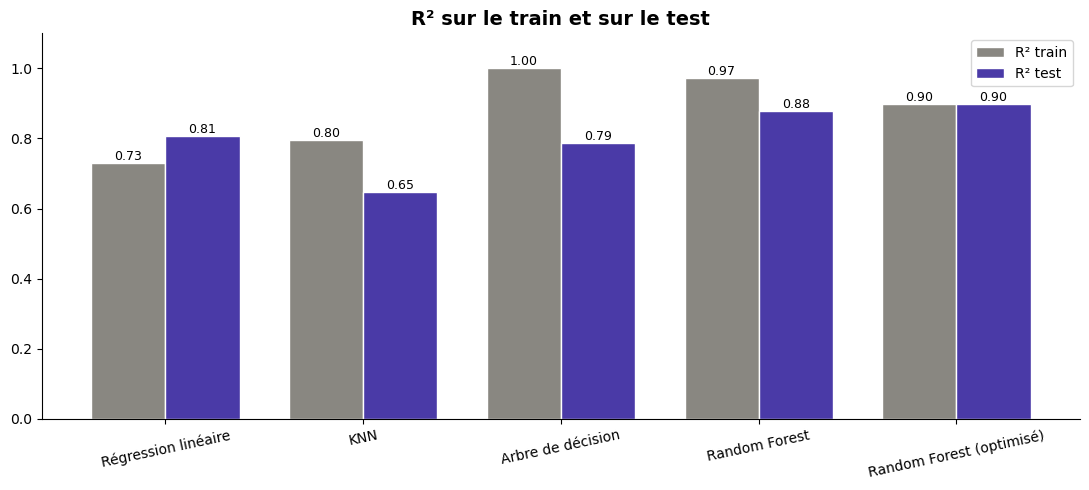

In [27]:
modeles_diag = {
    "Régression linéaire": lr, "KNN": knn, "Arbre de décision": tree,
    "Random Forest": rf, "Random Forest (optimisé)": best_rf,
}
lignes = []
for nom, modele in modeles_diag.items():
    pred_train = modele.predict(X_train_processed)
    pred_test = modele.predict(X_test_processed)
    lignes.append({
        "Modèle": nom,
        "R² train": metrics.r2_score(y_train, pred_train),
        "R² test": metrics.r2_score(y_test, pred_test),
        "MAE train": metrics.mean_absolute_error(y_train, pred_train),
        "MAE test": metrics.mean_absolute_error(y_test, pred_test),
    })
diagnostic = pd.DataFrame(lignes).set_index("Modèle")
diagnostic["Écart R²"] = diagnostic["R² train"] - diagnostic["R² test"]
display(diagnostic.round(3))

ax = diagnostic[["R² train", "R² test"]].plot(kind="bar", figsize=(11, 5), color=["#898781", "#4a3aa7"], edgecolor="white", width=0.75)
for conteneur in ax.containers:
    ax.bar_label(conteneur, fmt="%.2f", fontsize=9)
ax.set_title("R² sur le train et sur le test", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylim(0, 1.1)
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

**Diagnostic du surapprentissage :** l'arbre de décision a un R² de 1.00 sur le train contre 0.79 sur le test : il apprend les données par cœur. Le KNN (0.80 contre 0.65) et le Random Forest par défaut (0.97 contre 0.88) surapprennent aussi. Après optimisation, le Random Forest obtient 0.90 sur le train comme sur le test : l'écart disparaît, le modèle généralise bien. Son R² sur le test (0.898) n'est pas inférieur au R² de validation croisée (0.837), donc le score n'est pas gonflé.

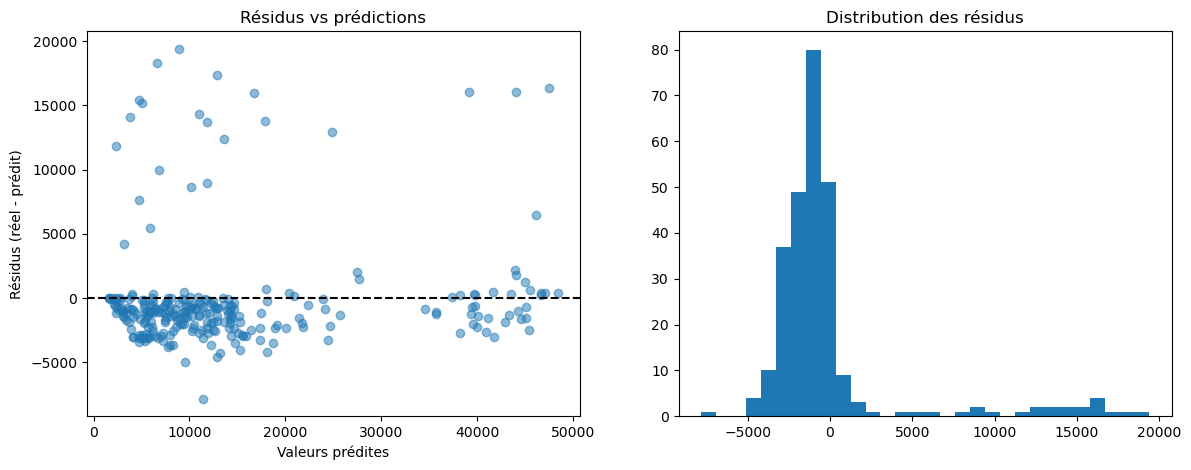

In [28]:
residuals = y_test - y_pred_best_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_best_rf, residuals, alpha=0.5)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("Valeurs prédites")
axes[0].set_ylabel("Résidus (réel - prédit)")
axes[0].set_title("Résidus vs prédictions")

axes[1].hist(residuals, bins=30)
axes[1].set_title("Distribution des résidus")
plt.show()

In [29]:
residuals_df = X_test.copy()
residuals_df["abs_residual"] = residuals.abs().values
residuals_df.groupby("smoker")["abs_residual"].mean()

smoker
no     2434.366361
yes    2543.350490
Name: abs_residual, dtype: float64

**Analyse des résidus :** les erreurs sont centrées autour de 0 (biais moyen ≈ -147 USD). L'erreur moyenne est similaire chez les fumeurs et les non-fumeurs (2 543 contre 2 434 USD) : le modèle est stable sur les deux groupes. Quelques cas à frais très élevés sont sous-estimés (résidus jusqu'à ≈ +19 000 USD).

In [30]:
import joblib

joblib.dump(best_rf, "model_rf.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

# Lot 1 : Tabagisme (Loïc)

Question principale :le tabagisme est-il le facteur qui influence le plus les frais médicaux, et de combien ?

Sous-questions :

1\. La distribution globale des frais révèle-t-elle un sous-groupe à part (les fumeurs) ?

2\. Quel est l'écart de coût chiffré entre fumeurs et non-fumeurs ?

3\. Ce surcoût est-il le même pour hommes et femmes ?


In [31]:
# KPI d'ouverture
cout_moyen = df["expenses"].mean()
cout_median = df["expenses"].median()
part_fumeurs = (df["smoker"] == "yes").mean()

print(f"Coût moyen du portefeuille  : {cout_moyen:,.0f} $")
print(f"Coût médian du portefeuille : {cout_median:,.0f} $")
print(f"Part de fumeurs             : {part_fumeurs:.1%}")

Coût moyen du portefeuille  : 13,279 $
Coût médian du portefeuille : 9,386 $
Part de fumeurs             : 20.5%


La moyenne (≈ 13 270 \$) est nettement au-dessus de la médiane (≈ 9 380 \$) : quelques assurés très coûteux tirent la moyenne vers le haut. La médiane décrit mieux l'assuré « typique », la moyenne reflète le coût réel à couvrir pour l'assureur.


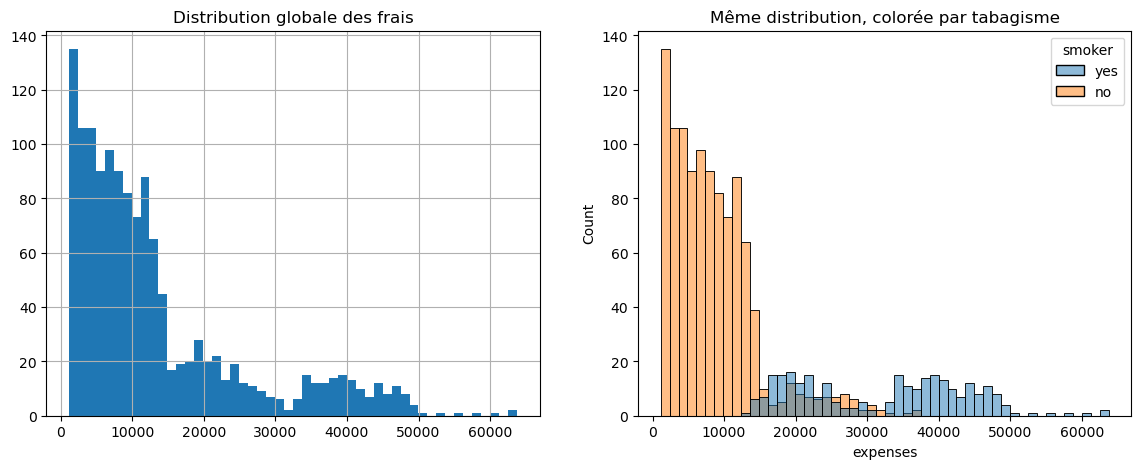

Assurés à plus de 30 000 $ : 162
dont fumeurs : 94%


In [32]:
# 1. La distribution globale des frais révèle-t-elle un sous-groupe à part ?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["expenses"].hist(bins=50, ax=axes[0])
axes[0].set_title("Distribution globale des frais")
sns.histplot(data=df, x="expenses", hue="smoker", bins=50, ax=axes[1])
axes[1].set_title("Même distribution, colorée par tabagisme")
plt.show()

# Qui sont les assurés les plus coûteux ?
gros_couts = df[df["expenses"] > 30000]
print(f"Assurés à plus de 30 000 $ : {len(gros_couts)}")
print(f"dont fumeurs : {(gros_couts['smoker'] == 'yes').mean():.0%}")


Réponse : oui. La distribution globale a une longue « queue » vers les frais élevés. En la colorant par tabagisme, on voit deux populations distinctes : les non-fumeurs sont concentrés sous ≈ 15 000 \\\$, tandis que les fumeurs forment un groupe à part, étalé de ≈ 15 000 à 60 000 \\\$. Sur les 162 assurés qui coûtent plus de 30 000 \\\$, **94 % sont fumeurs


In [33]:
# 2. Quel est l'écart de coût chiffré entre fumeurs et non-fumeurs ?
stats_tabac = df.groupby("smoker")["expenses"].agg(["count", "mean", "median"])
stats_tabac["part_des_assures"] = stats_tabac["count"] / len(df)
stats_tabac["part_des_depenses"] = df.groupby("smoker")["expenses"].sum() / df["expenses"].sum()
display(stats_tabac.round(2))

ratio = stats_tabac.loc["yes", "mean"] / stats_tabac.loc["no", "mean"]
print(f"Un fumeur coûte en moyenne {ratio:.1f} fois plus cher qu'un non-fumeur")

ecart_moyen = stats_tabac.loc["yes", "mean"] - stats_tabac.loc["no", "mean"]
ecart_median = stats_tabac.loc["yes", "median"] - stats_tabac.loc["no", "median"]
print(f"Écart de coût moyen  : +{ecart_moyen:,.0f} $ par fumeur")
print(f"Écart de coût médian : +{ecart_median:,.0f} $ par fumeur")

,count,mean,median,part_des_assures,part_des_depenses
smoker,,,,,
no,1063,8440.66,7345.73,0.8,0.51
yes,274,32050.23,34456.35,0.2,0.49


Un fumeur coûte en moyenne 3.8 fois plus cher qu'un non-fumeur
Écart de coût moyen  : +23,610 $ par fumeur
Écart de coût médian : +27,111 $ par fumeur


Réponse : un fumeur coûte en moyenne 32 050 \$ contre 8 434 \$ pour un non-fumeur, soit +23 616 \\\$ (≈ 3,8 fois plus). En médiane, l'écart est encore plus grand : +27 111 \\\$. Les fumeurs ne représentent que 20 % des assurés mais 49 % des dépenses totales.


smoker,no,yes,surcout,ratio
sex,,,,
female,8762.3,30679.00,21916.70,3.50
male,8099.7,33042.01,24942.31,4.08


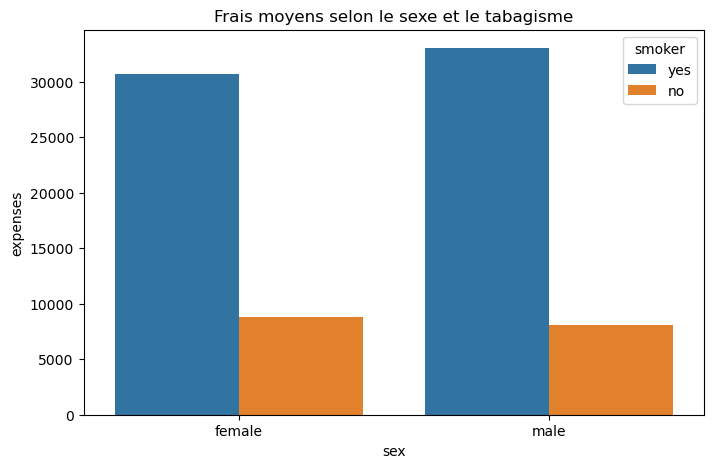

In [34]:
# 3. Ce surcoût est-il le même pour hommes et femmes ?

surcout_sexe = df.pivot_table(index="sex", columns="smoker", values="expenses", aggfunc="mean")
surcout_sexe["surcout"] = surcout_sexe["yes"] - surcout_sexe["no"]
surcout_sexe["ratio"] = surcout_sexe["yes"] / surcout_sexe["no"]
display(surcout_sexe.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="sex", y="expenses", hue="smoker", errorbar=None)
plt.title("Frais moyens selon le sexe et le tabagisme")
plt.show()

Réponse : le surcoût existe pour les deux sexes et il est du même ordre de grandeur : +21 917 \$ (x3,5) chez les femmes et +24 955 \$ (x4,1) chez les hommes. Il est un peu plus marqué chez les hommes (≈ 3 000 \$ de plus). Le sexe seul, en revanche, ne change presque rien : chez les non-fumeurs, femmes et hommes coûtent à peu près pareil (≈ 8 760 \$ contre 8 090 \$).


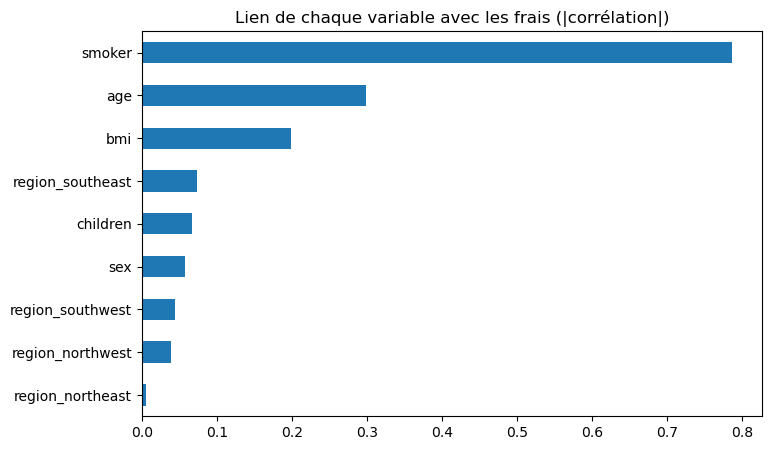

smoker              0.787
age                 0.298
bmi                 0.199
region_southeast    0.074
children            0.067
sex                 0.058
region_southwest    0.044
region_northwest    0.039
region_northeast    0.006
Name: expenses, dtype: float64

In [35]:
# Le tabagisme est-il le facteur n°1 ?
# Copie sans la colonne catégorielle "age_group" (créée plus bas)
df_num = df.drop(columns=["age_group"], errors="ignore").copy()

# Encodage binaire des variables catégorielles
df_num["smoker"] = (df_num["smoker"] == "yes").astype(int)
df_num["sex"] = (df_num["sex"] == "male").astype(int)
df_num = pd.get_dummies(df_num, columns=["region"], dtype=int)

# Force du lien (corrélation en valeur absolue) avec les frais
influence = df_num.corr()["expenses"].drop("expenses").abs().sort_values()
influence.plot(
    kind="barh",
    figsize=(8, 5),
    title="Lien de chaque variable avec les frais (|corrélation|)",
)
plt.show()
influence.sort_values(ascending=False).round(3)

Conclusion du Lot 1 :

Oui, le tabagisme est de loin le facteur qui influence le plus les frais médicaux. Sa corrélation avec les frais (0,79) est plus de 2,5 fois celle de l'âge (0,30), le 2e facteur, et 4 fois celle de l'IMC (0,20). Le sexe, le nombre d'enfants et la région pèsent très peu (&lt; 0,08).

Être fumeur ajoute en moyenne ≈ 23 600 \$ de frais par an (x3,8), pour les hommes comme pour les femmes. Les fumeurs forment un sous-groupe à part : 20 % des assurés, mais la moitié des dépenses et 94 % des assurés à plus de 30 000 \$.

Pour Aegis, le statut fumeur doit être le premier critère de tarification.


# Lot 2 : BMI & âge (Suz)

# KPI — BMI moyen du portefeuille (suz)

In [36]:
bmi_moyen = df["bmi"].mean()

print(f"BMI moyen du portefeuille : {bmi_moyen:.1f}")

BMI moyen du portefeuille : 30.7


 Le BMI moyen (30.7) dépasse déjà le seuil d'obésité (30) — la population assurée présente en moyenne un facteur de risque de santé notable.

\# Question principale : Le BMI et l'âge amplifient-ils l'effet du tabagisme sur les frais ?


\#  L'IMC élevé augmente-t-il les frais pareil chez fumeurs et non-fumeurs ? Code analyse :


In [37]:
correlation_bmi = df["bmi"].corr(df["expenses"])
print(f"Corrélation BMI / frais : {correlation_bmi:.2f}")

Corrélation BMI / frais : 0.20


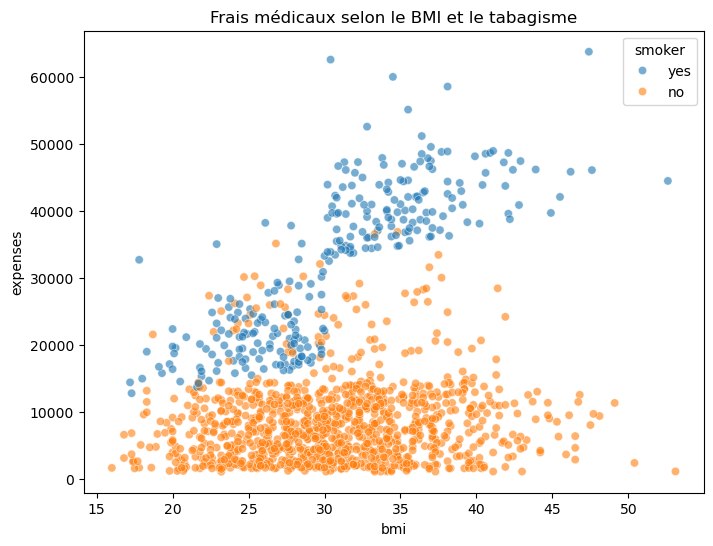

In [38]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="bmi", y="expenses", hue="smoker", alpha=0.6)
plt.title("Frais médicaux selon le BMI et le tabagisme")
plt.show()

Chez les fumeurs, les frais grimpent nettement avec le BMI ; chez les non-fumeurs, la relation reste quasi plate.

# Le vieillissement aggrave-t-il plus les coûts chez les fumeurs ?

In [39]:
correlation_age = df["age"].corr(df["expenses"])
print(f"Corrélation âge / frais : {correlation_age:.2f}")

Corrélation âge / frais : 0.30


 Corrélation modérée positive (0.30) — les frais augmentent globalement avec l'âge.

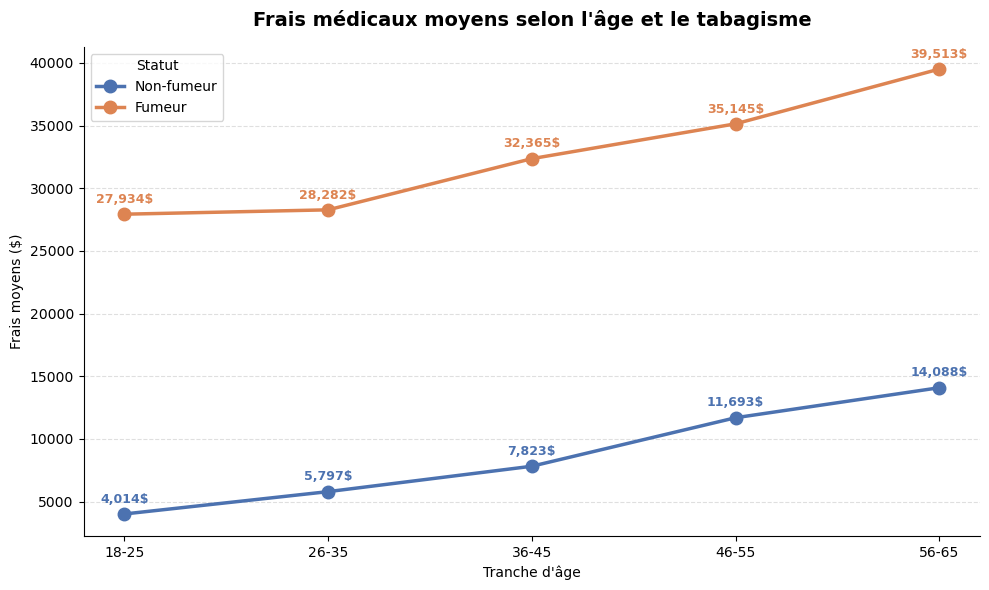

In [40]:
df["age_group"] = pd.cut(df["age"], bins=[17, 25, 35, 45, 55, 65], 
                          labels=["18-25", "26-35", "36-45", "46-55", "56-65"])

frais_age_smoker = df.groupby(["age_group", "smoker"], observed=True)["expenses"].mean().unstack()

plt.figure(figsize=(10, 6))
for smoker_status, color, label in [("no", "#4C72B0", "Non-fumeur"), ("yes", "#DD8452", "Fumeur")]:
    plt.plot(frais_age_smoker.index, frais_age_smoker[smoker_status], 
             marker="o", markersize=9, linewidth=2.5, color=color, label=label)
    for x, y in zip(frais_age_smoker.index, frais_age_smoker[smoker_status]):
        plt.text(x, y + 900, f"{y:,.0f}$", ha="center", fontsize=9, color=color, fontweight="bold")

plt.title("Frais médicaux moyens selon l'âge et le tabagisme", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Tranche d'âge")
plt.ylabel("Frais moyens ($)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend(title="Statut", frameon=True)
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

L'écart entre fumeurs et non-fumeurs reste stable (~24 000-25 000$) à tout âge — le tabagisme est une pénalité quasi constante, pas un effet qui s'accumule avec l'âge.

Existe-t-il un effet de seuil au BMI=30 qui amplifie le surcoût du tabagisme ?

In [41]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 25, 30, 100], labels=["Normal (<25)", "Surpoids (25-30)", "Obésité (>=30)"])
frais_bmi_smoker = df.groupby(["bmi_category", "smoker"], observed=True)["expenses"].mean().round(2)
print(frais_bmi_smoker)

bmi_category      smoker
Normal (<25)      no         7547.18
                  yes       19839.28
Surpoids (25-30)  no         8254.22
                  yes       22633.50
Obésité (>=30)    no         8857.00
                  yes       41751.45
Name: expenses, dtype: float64


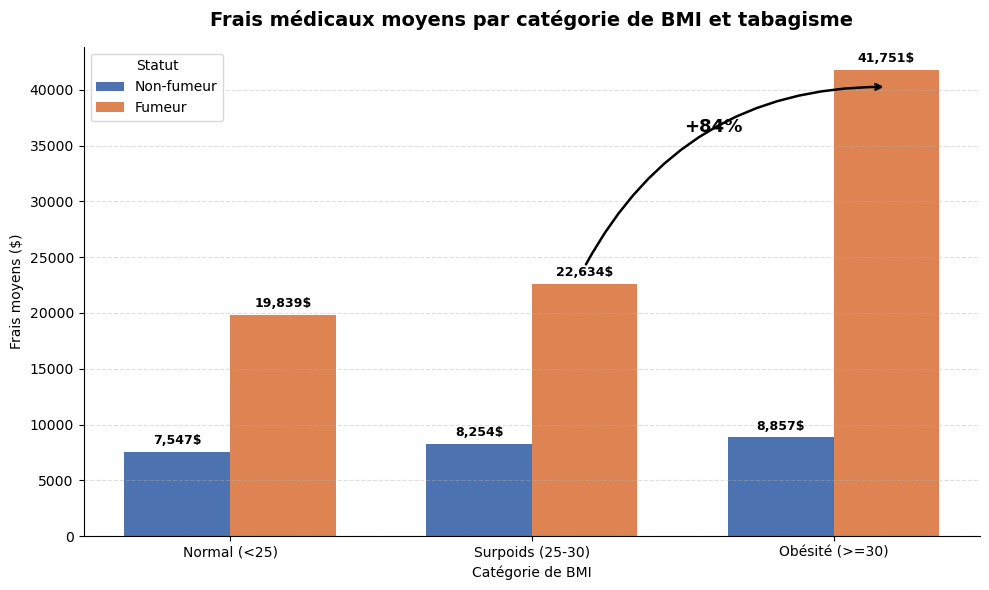

In [42]:
frais_bmi_smoker_wide = df.groupby(["bmi_category", "smoker"], observed=True)["expenses"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(frais_bmi_smoker_wide.index))
width = 0.35

bars_no = ax.bar(x - width/2, frais_bmi_smoker_wide["no"], width, label="Non-fumeur", color="#4C72B0")
bars_yes = ax.bar(x + width/2, frais_bmi_smoker_wide["yes"], width, label="Fumeur", color="#DD8452")

for bars in [bars_no, bars_yes]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 700, f"{height:,.0f}$",
                ha="center", fontsize=9, fontweight="bold")

# Annotation du saut +84% chez les fumeurs (Surpoids -> Obésité)
y1 = frais_bmi_smoker_wide["yes"].iloc[1]
y2 = frais_bmi_smoker_wide["yes"].iloc[2]
ax.annotate("", xy=(2 + width/2, y2 - 1500), xytext=(1 + width/2, y1 + 1500),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.8, connectionstyle="arc3,rad=-0.3"))
ax.text(1.6, (y1 + y2) / 2 + 4000, "+84%", fontsize=13, fontweight="bold", color="black", ha="center")

ax.set_title("Frais médicaux moyens par catégorie de BMI et tabagisme", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Catégorie de BMI")
ax.set_ylabel("Frais moyens ($)")
ax.set_xticks(x)
ax.set_xticklabels(frais_bmi_smoker_wide.index)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Statut", frameon=True)
plt.tight_layout()
plt.show()

 L'obésité ne fait quasiment pas varier les frais chez les non-fumeurs (+17%), mais elle fait exploser ceux des fumeurs (+84%). 
 
Le tabagisme et l'obésité ne s'additionnent pas : ils se multiplient C'est ce croisement — pas l'un ou l'autre facteur isolé — qui doit piloter la tarification Aegis.

Conclusion — Lot 2 : BMI & âge

L'âge augmente les frais de façon régulière, mais l'écart entre fumeurs et non-fumeurs reste constant (~24 000-25 000$) à tout âge — le tabagisme pèse dès le départ, il ne s'aggrave pas avec le temps.

Le BMI a un impact très différent selon le statut tabagique : presque nul chez les non-fumeurs, très fort chez les fumeurs (+84% une fois en obésité). Tabagisme et obésité ne s'additionnent pas : ils se multiplient

Conclusion : le BMI amplifie fortement l'effet du tabagisme, l'âge non. Aegis devrait donc tarifer le profil "fumeur + BMI élevé" comme une catégorie de risque à part.

# region et famille

Lot 3 : Région & famille ( david)

KPI d'ouverture : Frais moyens par région

Question principale : Les caractéristiques démographiques justifient-elles une différenciation tarifaire face au tabagisme/BMI ?

Sous-questions :

7. Le lieu de résidence justifie-t-il une différenciation régionale ?
8. La taille du foyer a-t-elle un impact significatif ?
9. Quelles variables doivent réellement entrer dans le modèle (corrélation) ?


In [43]:
frais_region = df.groupby("region")["expenses"].mean().sort_values()
print(frais_region.round(0))

region
southwest    12347.0
northwest    12451.0
northeast    13406.0
southeast    14735.0
Name: expenses, dtype: float64


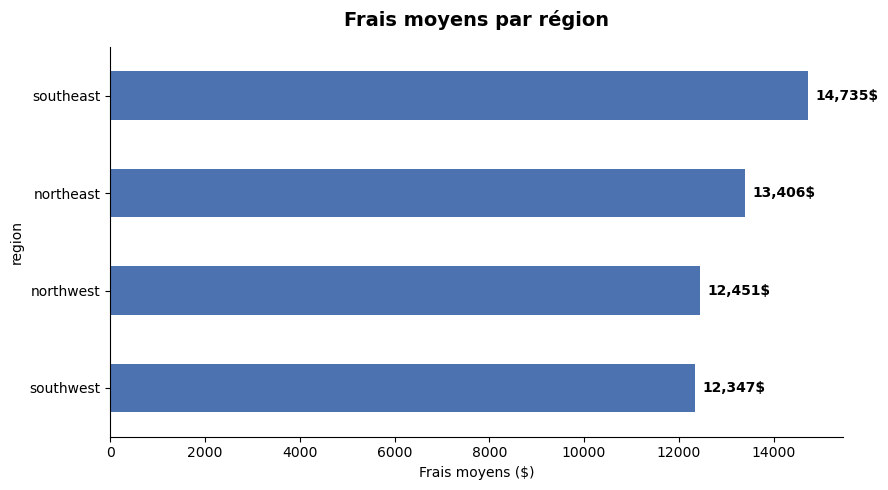

In [44]:
plt.figure(figsize=(9, 5))
ax = frais_region.plot(kind="barh", color="#4C72B0")
for i, v in enumerate(frais_region):
    ax.text(v + 150, i, f"{v:,.0f}$", va="center", fontweight="bold")
plt.title("Frais moyens par région", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Frais moyens ($)")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# le lieu de résidence justifie-t-il une différenciation régionale ?

In [45]:
profil_region = df.groupby("region").agg(
    frais_moyens=("expenses", "mean"),
    part_fumeurs=("smoker", lambda s: (s == "yes").mean()),
    bmi_moyen=("bmi", "mean"),
).round(2)
display(profil_region.sort_values("frais_moyens", ascending=False))

,frais_moyens,part_fumeurs,bmi_moyen
region,,,
southeast,14735.41,0.25,33.36
northeast,13406.38,0.21,29.18
northwest,12450.84,0.18,29.20
southwest,12346.94,0.18,30.60


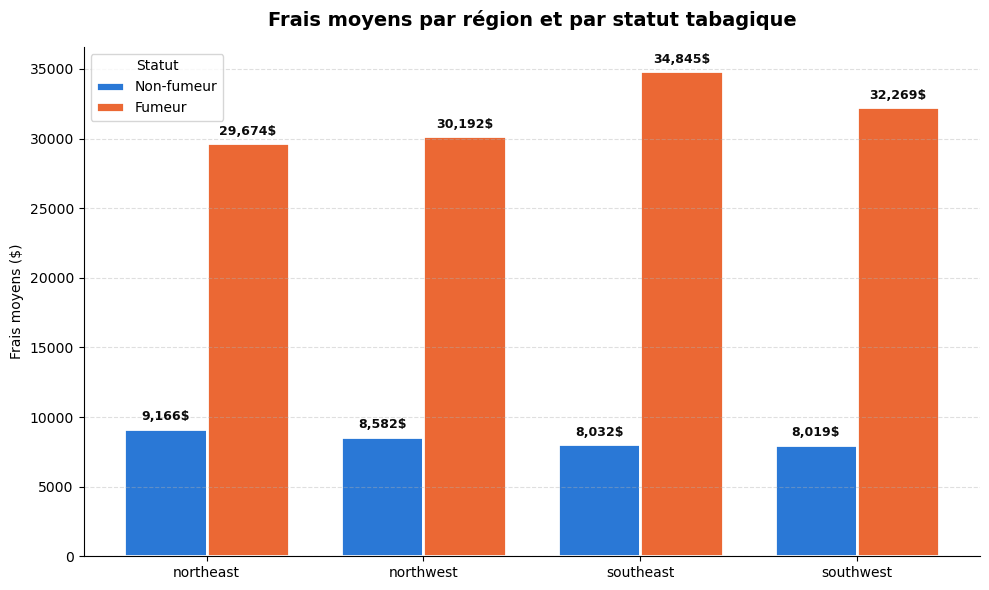

In [46]:
COULEURS_TABAC = {"no": "#2a78d6", "yes": "#eb6834"}   # non-fumeur = bleu, fumeur = orange

frais_reg_smoker = df.groupby(["region", "smoker"])["expenses"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(frais_reg_smoker.index))
width = 0.38
bars_no = ax.bar(x - width/2, frais_reg_smoker["no"], width, label="Non-fumeur",
                 color=COULEURS_TABAC["no"], edgecolor="white", linewidth=2)
bars_yes = ax.bar(x + width/2, frais_reg_smoker["yes"], width, label="Fumeur",
                  color=COULEURS_TABAC["yes"], edgecolor="white", linewidth=2)
for bars in (bars_no, bars_yes):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 600, f"{h:,.0f}$",
                ha="center", fontsize=9, fontweight="bold", color="#0b0b0b")
ax.set_xticks(x)
ax.set_xticklabels(frais_reg_smoker.index)
ax.set_title("Frais moyens par région et par statut tabagique", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Frais moyens ($)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Statut", frameon=True)
plt.tight_layout()
plt.show()

La région la plus chère (Sud-Est) est aussi celle qui compte le plus de fumeurs (25%) et le BMI moyen le plus élevé (33.4) : l'écart vient surtout du profil des assurés, pas du lieu de résidence. Chez les non-fumeurs, les frais restent proches d'une région à l'autre (8 019 à
). Chez les fumeurs ils varient davantage (29 674 à
), mais l'écart entre fumeurs et non-fumeurs est partout bien plus grand que l'écart entre régions. Une tarification régionale n'est donc pas prioritaire.

# La taille du foyer a-t-elle un impact significatif ?


In [47]:
foyer = df.groupby("children")["expenses"].agg(["count", "mean"]).round(0)
print(foyer)
print(f"Corrélation enfants / frais : {df['children'].corr(df['expenses']):.2f}")

          count     mean
children                
0           573  12385.0
1           324  12731.0
2           240  15074.0
3           157  15355.0
4            25  13851.0
5            18   8786.0
Corrélation enfants / frais : 0.07


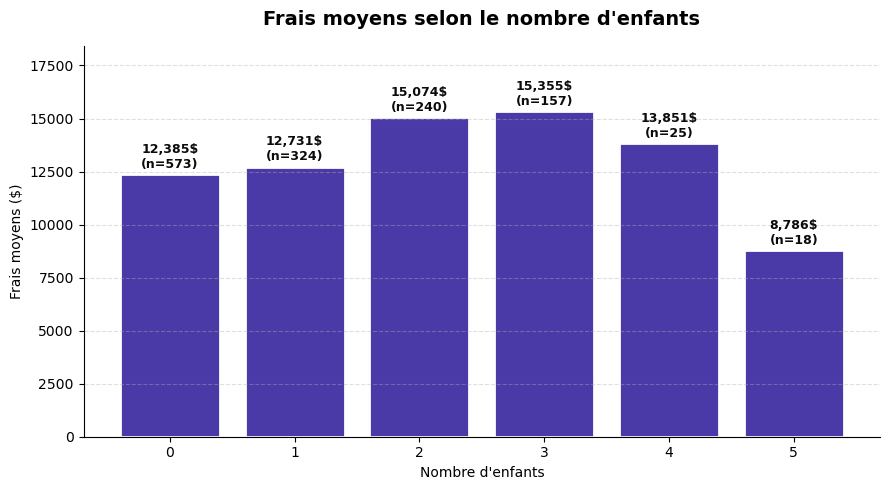

In [48]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(foyer.index.astype(str), foyer["mean"], color="#4a3aa7", edgecolor="white", linewidth=2)
for bar, n in zip(bars, foyer["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{bar.get_height():,.0f}$\n(n={int(n)})", ha="center", fontsize=9,
            fontweight="bold", color="#0b0b0b")
ax.set_title("Frais moyens selon le nombre d'enfants", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Nombre d'enfants")
ax.set_ylabel("Frais moyens ($)")
ax.set_ylim(0, foyer["mean"].max() * 1.2)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Les frais moyens montent de 12 385 à
 (3 enfants), puis retombent à 13 851 
 (5 enfants). Les groupes à 4 et 5 enfants sont très petits (25 et 18 assurés) : cette baisse n'est pas fiable. La corrélation entre enfants et frais est de 0.07 : effet faible, le nombre d'enfants n'est pas un critère de tarification.

 # Quelles variables doivent réellement entrer dans le modèle (corrélation) ?

In [49]:
df_num = df.drop(columns=["age_group", "bmi_category"], errors="ignore").copy()
df_num["smoker"] = (df_num["smoker"] == "yes").astype(int)
df_num["sex"] = (df_num["sex"] == "male").astype(int)
df_num = pd.get_dummies(df_num, columns=["region"], drop_first=True, dtype=int)
corr = df_num.corr()
print(corr["expenses"].drop("expenses").sort_values(ascending=False).round(2))

smoker              0.79
age                 0.30
bmi                 0.20
region_southeast    0.07
children            0.07
sex                 0.06
region_northwest   -0.04
region_southwest   -0.04
Name: expenses, dtype: float64


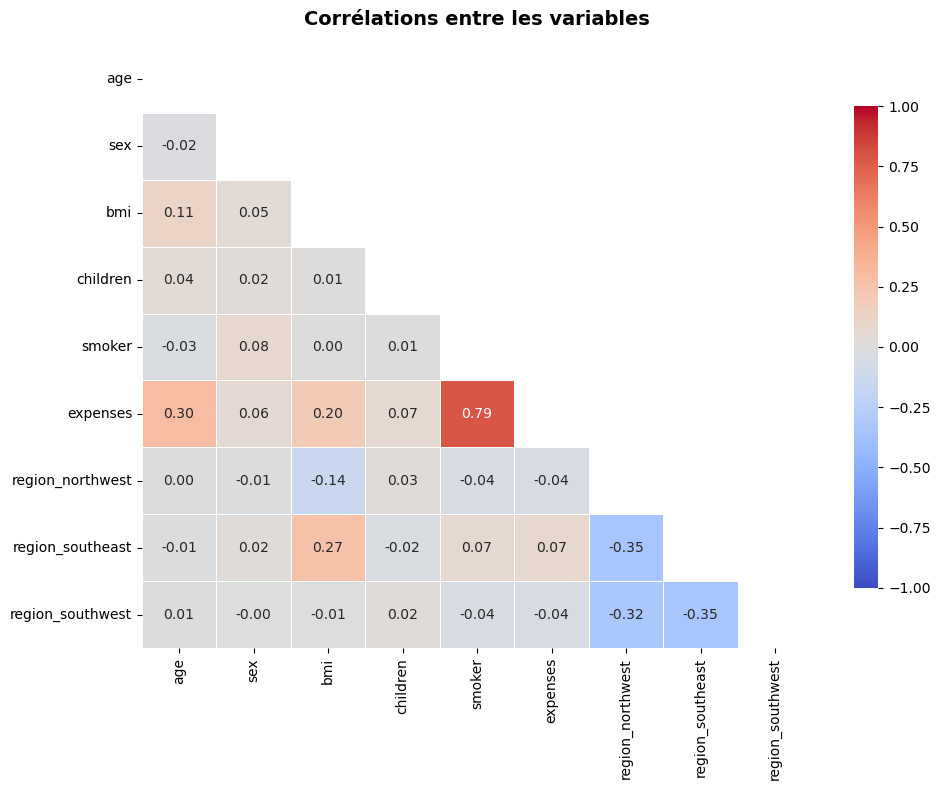

In [50]:
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Corrélations entre les variables", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

Le statut fumeur domine (0.79), suivi de l'âge (0.30) et du BMI (0.20). Sexe, enfants et région restent sous 0.08. Les variables explicatives sont peu corrélées entre elles (au plus 0.35) : pas de redondance à corriger. Le BMI reste indispensable malgré sa corrélation modérée, car son effet passe par l'interaction avec le tabagisme, que la corrélation seule ne voit pas (voir la section 9).

## Conclusion — Lot 3 : région & famille

Les caractéristiques démographiques ne justifient pas de différenciation tarifaire face au tabagisme et au BMI. La région crée un écart d'environ 2 400 $, qui s'explique surtout par le profil des assurés. Le nombre d'enfants n'a pas d'effet clair. Aegis doit tarifer d'abord sur le statut fumeur, le BMI et l'âge.

## Conclusion et recommandations

**Modèle retenu : Random Forest optimisé** (max_depth=10, min_samples_leaf=5, n_estimators=200). Sur le jeu de test : R² = 0.898, MAE ≈ 2 459 USD, RMSE ≈ 4 329 USD. Il explique 90 % de la variabilité des frais, sans surapprentissage, et il est meilleur que la régression linéaire, le KNN et l'arbre de décision.

**Ce qui pilote les frais :** le statut fumeur (66 %), puis le BMI (19 %) et l'âge (13 %). Chez les fumeurs, passer en obésité fait bondir les frais de 84 %, contre 17 % chez les non-fumeurs.

**Recommandations pour Aegis :**
1. Tarifer d'abord selon le statut fumeur.
2. Ajuster par le BMI et l'âge, avec une catégorie de risque à part pour « fumeur + BMI ≥ 30 ».
3. Ne pas différencier selon le sexe, la région ou le nombre d'enfants.

**Limites :** un peu plus de 1 300 assurés seulement ; les frais très élevés sont les moins bien prédits ; peu de variables (pas d'antécédents médicaux).